## Customer Churn Prediction

#### Business Probelm: - Predict whether a telecom customer is likely to churn based on usage behavior.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\rahul\Downloads\iranian+churn+dataset\Customer Churn.csv")

In [3]:
df

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,21,0,19,2,6697,147,92,44,2,2,1,25,721.980,0
3146,17,0,17,1,9237,177,80,42,5,1,1,55,261.210,0
3147,13,0,18,4,3157,51,38,21,3,1,1,30,280.320,0
3148,7,0,11,2,4695,46,222,12,3,1,1,30,1077.640,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)

In [5]:
df.shape

(3150, 14)

In [6]:
df.duplicated().sum()

np.int64(300)

In [7]:
df = df.drop_duplicates()

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(2850, 14)

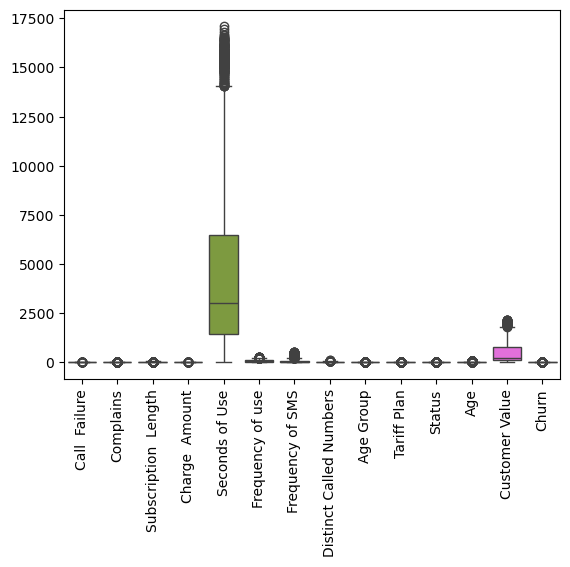

In [10]:
sns.boxplot(data = df)

plt.xticks(rotation=90)
plt.show()

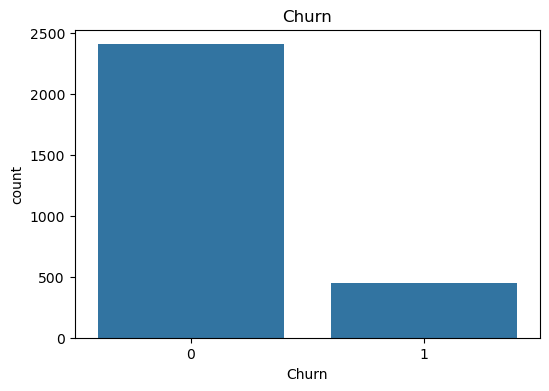

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Churn")
plt.show()

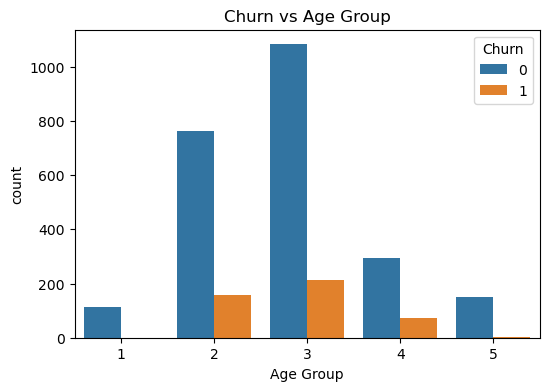

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Age Group", hue="Churn")
plt.title("Churn vs Age Group")
plt.show()

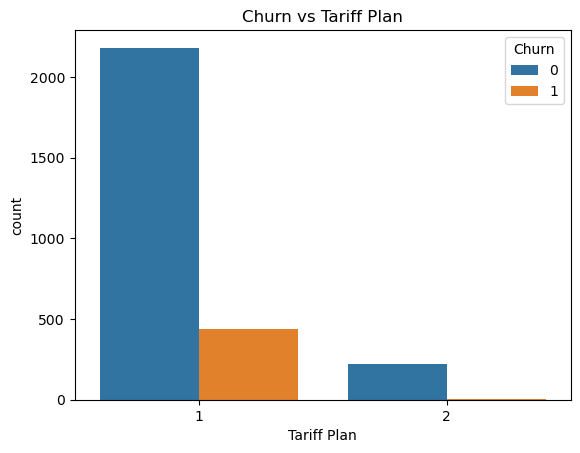

In [13]:
sns.countplot(data= df, x="Tariff Plan", hue="Churn")
plt.title("Churn vs Tariff Plan")
plt.show()

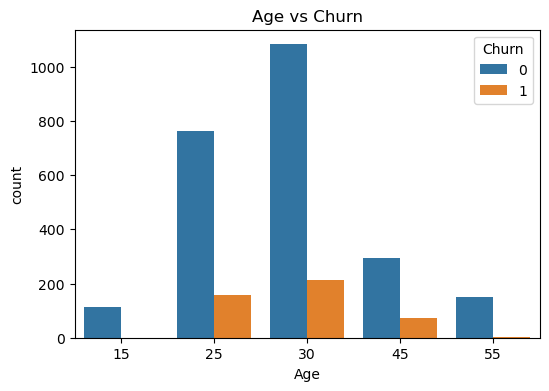

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Age", hue="Churn")
plt.title("Age vs Churn")
plt.show()

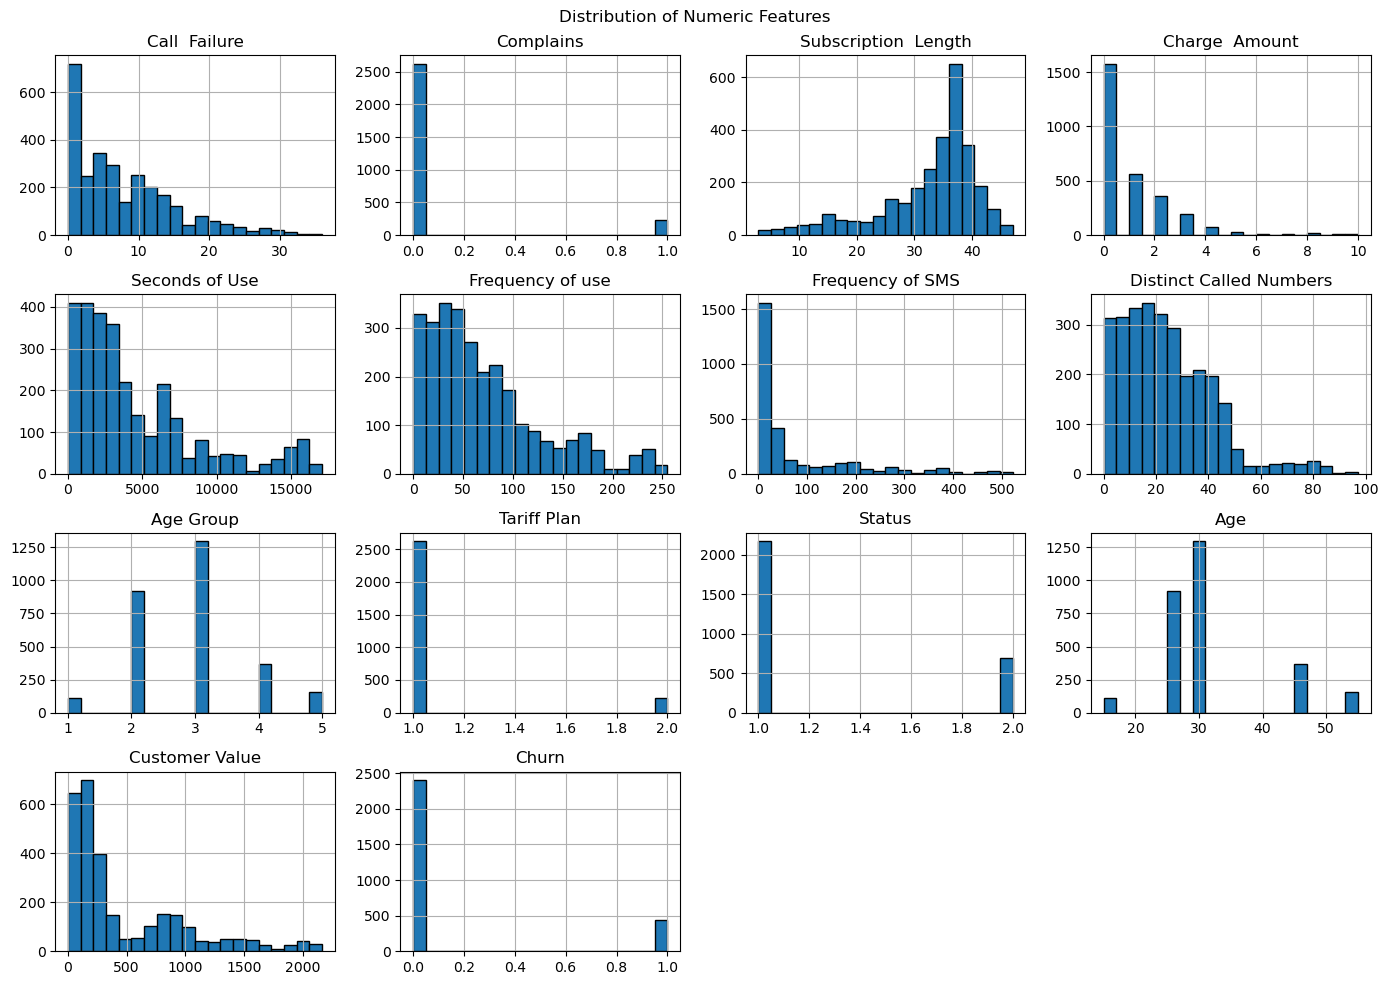

In [15]:
numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].hist(
    figsize=(14,10),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.show()

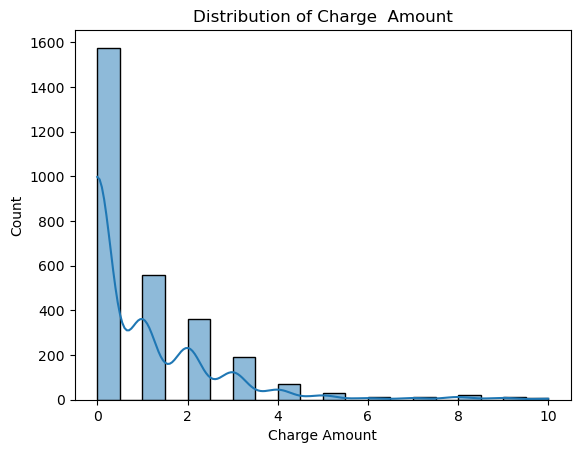

In [16]:
sns.histplot(df["Charge  Amount"],bins=20, kde=True)
plt.title("Distribution of Charge  Amount")
plt.xlabel("Charge Amount")
plt.ylabel("Count")
plt.show()

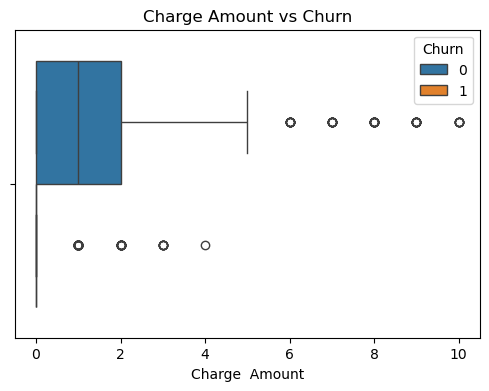

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Charge  Amount", hue="Churn")
plt.title("Charge Amount vs Churn")
plt.show()

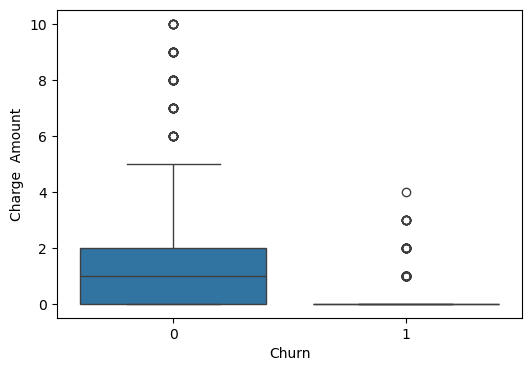

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="Charge  Amount")
plt.show()

In [19]:
# Churn imbalance check
df["Churn"].value_counts(normalize=True) * 100

Churn
0    84.350877
1    15.649123
Name: proportion, dtype: float64

In [20]:
## Check Skewness

df.select_dtypes(include="number").skew().sort_values(ascending=False)

Tariff Plan                3.089147
Complains                  3.080435
Charge  Amount             2.533804
Frequency of SMS           1.971020
Churn                      1.891937
Customer Value             1.422214
Seconds of Use             1.314737
Age                        1.223952
Status                     1.218203
Frequency of use           1.145862
Call  Failure              1.067233
Distinct Called Numbers    1.039277
Age Group                  0.453043
Subscription  Length      -1.252843
dtype: float64

In [21]:
def cap_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower, upper)
    return df

In [22]:
cols_to_cap = [
    "Seconds of Use",
    "Customer Value",
    "Charge  Amount",
    "Frequency of use",
    "Frequency of SMS"
]

df = cap_outliers(df, cols_to_cap)

C:\Users\rahul\AppData\Local\Temp\ipykernel_10768\3831789791.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].clip(lower, upper)
C:\Users\rahul\AppData\Local\Temp\ipykernel_10768\3831789791.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].clip(lower, upper)
C:\Users\rahul\AppData\Local\Temp\ipykernel_10768\3831789791.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

In [23]:
df.head(2)

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370.0,71,5.0,17,3,1,1,30,197.640,0
1,0,0,39,0,318.0,5,7.0,4,2,1,2,25,46.035,0


#### Feature preparation

In [24]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2280, 13)
(570, 13)
(2280,)
(570,)


In [26]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(include="object").columns

preprocess = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [27]:
X_train_trans = preprocess.fit_transform(X_train)
X_test_trans = preprocess.transform(X_test)

In [28]:
X_train_trans = pd.DataFrame(X_train_trans)
X_train_trans.head(2)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-0.786822,-0.295411,-1.987462,0.833929,-0.578108,-0.648867,-0.709505,-0.281288,0.203969,-0.296287,-0.561816,-0.10433,-0.722250
1,-0.649984,-0.295411,-2.558529,0.833929,-0.714311,-0.817043,-0.360039,-0.748053,0.203969,-0.296287,-0.561816,-0.10433,-0.556387


In [29]:
X_test_trans = pd.DataFrame(X_test_trans)
X_test_trans.head(2)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.676274,-0.295411,-0.502689,0.068795,2.433982,2.415657,-0.790151,2.927725,-0.92206,-0.296287,-0.561816,-0.67477,0.497481
1,0.034210,3.385117,-0.274262,-0.696340,0.285097,0.360183,-0.642300,-0.339633,-0.92206,-0.296287,-0.561816,-0.67477,-0.333196


In [30]:
## model Knn Classifiers
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors= 11,
    weights="uniform",
    metric="minkowski"
)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=11)

In [31]:
y_pred = knn.predict(X_test)
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test,y_pred)
print(acc)

0.8526315789473684


In [32]:
y_pred_train = knn.predict(X_train)
acc_train = accuracy_score(y_train,y_pred_train)
print(acc_train)

0.8657894736842106


In [33]:
## using knn is was giving more gap which is not suitable for churn data, by using k neigbhor = 11 it give less gap
## or after tuning it accuracy is better

In [34]:
## knn 
for k in range(3, 21, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_trans, y_train)
    print(k, knn.score(X_train_trans, y_train), knn.score(X_test_trans, y_test))

3 0.975 0.9456140350877194
5 0.9728070175438597 0.9473684210526315
7 0.9644736842105263 0.9421052631578948
9 0.9587719298245614 0.9385964912280702
11 0.9530701754385965 0.9421052631578948
13 0.9517543859649122 0.9438596491228071
15 0.9482456140350877 0.9333333333333333
17 0.9421052631578948 0.9263157894736842
19 0.9429824561403509 0.9228070175438596


### Naive bayes

In [35]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('prep',preprocess),
    ('model',GaussianNB())
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred)
print(acc_nb)

0.7684210526315789


In [36]:
y_pred_train = pipe.predict(X_train)
acc_train_nb = accuracy_score(y_train,y_pred_train)
print(acc_train_nb)

0.7478070175438597


### Decision tree

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

pipe1 = Pipeline([
    ('prep',preprocess),
    ('model',DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
        
    ))
])

pipe1.fit(X_train, y_train)

y_pred_dt = pipe1.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(acc_dt)

0.9210526315789473


In [38]:
y_pred1_dt = pipe1.predict(X_train)
acc_dt_train = accuracy_score(y_train, y_pred1_dt)
print(acc_dt_train)

0.9350877192982456


In [39]:
# By using max_depth it acctually reduces the gap(overfitting)

In [40]:
from sklearn.metrics import classification_report
y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.74      0.84       479
           1       0.40      0.91      0.56        91

    accuracy                           0.77       570
   macro avg       0.69      0.83      0.70       570
weighted avg       0.89      0.77      0.80       570



 The initial Decision Tree showed slight overfitting; max_depth tuning was performed to improve generalization.

In [41]:
import pickle

In [42]:

with open("Churn_pred.pkl","wb") as file:
    pickle.dump(pipe1, file)